# Which experiment to run next

One coherence signal has been measured and fitted, and the posterior still
holds several explanations of it. Given a list of experiments that could be
run next, each a different pulse number on a grid of delays, this notebook
works out which one to run and at which delays:

1. **Simulate every hypothesis.** The posterior is reduced to a weighted set
   of distinct baths, and each candidate experiment is simulated for all of
   them.
2. **Find where they disagree.** At each delay, the weighted variance of the
   simulated signals says how much a measurement there could tell the baths
   apart.
3. **Charge for time.** One repetition of a sequence with $N$ pulses at
   delay $\tau$ takes $2N\tau$. Every candidate gets the same total time,
   so a slow point is measured fewer times and is noisier.
4. **Choose pulse number and delays together.** Each candidate is given its
   own best set of delays, and the candidates are then compared by the
   expected information gain of those designs.
5. **Say so when nothing would help.** If the best design on the list gains
   less than a set threshold, the answer is that no experiment on the list
   can tell the baths apart, and no experiment is returned.

**The output is one experiment**: a pulse number and the delays to measure
at, with how the measurement time is to be shared between them. Section 6
prints it as a table to hand to whoever runs the measurement.

This notebook is where the procedure was first worked out, as a standalone
prototype. It now runs on the package: section 4 sets up
`nuclear_spin_recovery.design.ExperimentDesigner`, which carries out the
five steps above, and nothing in the calculation is local to the notebook.

In [1]:
import collections
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from nuclear_spin_recovery import (
    RJMCMC,
    RWMH,
    AnalyticCCE1,
    BirthDeathKernel,
    DecouplingScaling,
    DiscreteLatticeWalk,
    ExpectedInformationGain,
    Experiment,
    ExperimentDesigner,
    ExperimentSet,
    GaussianL2,
    HybridDriver,
    InformationDensity,
    NeighborIndex,
    ParameterBlock,
    ParticleSet,
    Schedule,
    SequenceDuration,
    SiteScaledOffset,
    SiteTable,
    State,
    Step,
    StretchedExponential,
    Target,
    Trace,
    gyromagnetic_ratio,
    measurement_table_html,
    merge_traces,
    simulate_dataset,
    write_measurement_csv,
)

# One colour per pulse number, in a fixed order, used in every figure.
PULSE_COLOURS = {4: "#2a78d6", 8: "#eb6834", 16: "#1baf7a", 32: "#eda100",
                 64: "#e87ba4"}
C_BEFORE, C_AFTER = "#898781", "#2a78d6"
C_INK, C_MUTED, C_GRID, C_AXIS = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
C_SOFT = "#f0efec"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C_AXIS, "axes.labelcolor": "#52514e",
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "grid.color": C_GRID, "grid.linewidth": 0.6, "legend.frameon": False,
    "figure.dpi": 110,
})

## 1. The system and the first measurement

The ten-site toy lattice of the relaxation notebooks, with three true spins
that each sit away from their table value, measured once with CPMG-4.

Unlike those notebooks, the signal here **decays**. Without decoherence a
sequence with more pulses always wins: its dips deepen faster than its
duration grows, and the question of which pulse number to use has no
content. The decay is a plain exponential in $\tau$. Its constant at four
pulses, $\lambda_4$, is set to **ten periods of the signal**: the dips
repeat every half Larmor period in $\tau$, 1.5 µs at this field, so
$\lambda_4$ = 15 µs and the modulation is still visible ten dips in. At
another pulse number

$$\lambda_N = \lambda_4\,(N/4)^{\gamma-1}.$$

This is the usual model in which the coherence time in *total* evolution
time grows as $N^\gamma$. **$\gamma$ is an assumption about the sample**, set
here to 2/3, and the design depends on it: it decides how quickly the longer
sequences lose their signal.

In [2]:
CENTRES = np.array([
    (100.0, 100.0), (10.0, 10.0), (100.0, 50.0), (60.0, 80.0), (150.0, 60.0),
    (40.0, 30.0), (75.0, 120.0), (130.0, 110.0), (25.0, 60.0), (55.0, 45.0)])
N_SITES, K_MAX = len(CENTRES), 6
TRUE = {2: (5.0, 2.0), 3: (-4.0, 5.0), 7: (8.0, -6.0)}   # site -> offset, kHz
TRUE_SITES = tuple(sorted(TRUE))
FRACTION = 0.10            # each coupling may relax by ±10% of its table value

B_Z = 311.0                # G
# The signal repeats in tau every half Larmor period, pi / omega_L.
SIGNAL_PERIOD = np.pi / (gyromagnetic_ratio("13C") * B_Z)      # ms
DECAY_PERIODS = 10         # the decay constant, in periods of the signal
LAMBDA_4 = DECAY_PERIODS * SIGNAL_PERIOD     # ms, in tau, at four pulses
GAMMA = 2.0 / 3.0          # coherence time grows as N ** GAMMA  (an assumption)
DATA_NOISE = 0.002         # noise of one point at unit measurement weight
LIK_SIGMA = 0.02           # the repo's calibrated likelihood width

_angle = np.linspace(0.0, 2.0 * np.pi, N_SITES, endpoint=False)
POSITIONS = np.column_stack([2.0 * np.cos(_angle), 2.0 * np.sin(_angle),
                             np.full(N_SITES, 2.0)])
table = SiteTable(
    distance=np.linalg.norm(POSITIONS, axis=1), positions=POSITIONS,
    a_par=CENTRES[:, 0], a_perp=CENTRES[:, 1],
    isotope=np.array(["13C"] * N_SITES),
    gyro=np.full(N_SITES, gyromagnetic_ratio("13C")))
model = AnalyticCCE1(StretchedExponential())


def decay_constant(n_pulses):
    """lambda at ``n_pulses``, scaled from the measured four-pulse value."""
    return LAMBDA_4 * (n_pulses / 4.0) ** (GAMMA - 1.0)


def make_state(sites, offsets=None, n_pulses=4):
    state = State.from_sites(
        tuple(int(s) for s in sites), n_sites=N_SITES, n_exp=1,
        lam=np.full((1, 1), decay_constant(n_pulses)),
        n_stretch=np.ones((1, 1)), sigma=np.full((1, 1), LIK_SIGMA),
        k_max=K_MAX, site_memory=True)
    if offsets is not None:
        for slot, (d_par, d_perp) in enumerate(offsets):
            state.set_offset(0, slot, 0, d_par)
            state.set_offset(0, slot, 1, d_perp)
    return state


def truth_state(n_pulses):
    return make_state(TRUE_SITES, [TRUE[s] for s in TRUE_SITES], n_pulses)


print(f"signal period {SIGNAL_PERIOD * 1e3:.2f} µs, decay constant at four "
      f"pulses {LAMBDA_4 * 1e3:.1f} µs")

tau_first = np.linspace(3.2e-5, 8e-3, 250)             # ms
first = ExperimentSet([Experiment(tau=tau_first, n_pulses=4, b_z=B_Z)])
data = simulate_dataset(truth_state(4), first, table, model, sigma=DATA_NOISE,
                        rng=np.random.default_rng(3))
target = Target(data, model, GaussianL2(), table)

signal period 1.50 µs, decay constant at four pulses 15.0 µs


## 2. The posterior

Four chains from different seeds, pooled. Each runs RJMCMC, a site walk and
an offset walk with site memory, as in `toy_rjmcmc_ten_sites`.

The chains are not tempered, and that notebook showed what follows: they
settle on different explanations and do not move between them. Pooled, they
give a spread of hypotheses, which is what a design needs. **The pooled
weights are not posterior probabilities.** A hypothesis that half the chains
found is not thereby half as likely as the truth. For choosing an experiment
to tell the hypotheses apart that matters less than it would for reporting
them, but it is the weakest input to everything below.

In [3]:
N_STEPS, N_BURN, N_CHAINS = 12000, 3000, 4


def run_chain(seed):
    schedule = Schedule([
        Step(RJMCMC(ParameterBlock("sites"), BirthDeathKernel(k_max=K_MAX)), 10),
        Step(RWMH(ParameterBlock("sites"),
                  DiscreteLatticeWalk(NeighborIndex(POSITIONS, 10.0))), 10),
        Step(RWMH(ParameterBlock("offsets"), SiteScaledOffset(
            1.0, table, fraction_par=FRACTION, fraction_perp=FRACTION,
            prior="flat")), 40),
    ])
    trace = Trace(n_sites=N_SITES, k_max=K_MAX, n_exp=1)
    HybridDriver(schedule).run(make_state((0,)), target,
                               np.random.default_rng(seed), N_STEPS, trace=trace)
    return trace.discard_burn_in(N_BURN)


pooled = merge_traces([run_chain(seed) for seed in range(N_CHAINS)])
print(f"{len(pooled)} pooled draws from {N_CHAINS} chains")

36000 pooled draws from 4 chains


## 3. From draws to baths

A design compares hypotheses, so the draws have to be grouped into distinct
baths first. Two draws are the same bath when their spins pair up with both
couplings within a tolerance.

The package's default tolerance is 0.1 kHz, chosen for couplings pinned to
their table values. With relaxation on, a coupling wanders by kilohertz
within one hypothesis, and at 0.1 kHz almost every draw is counted as its
own bath. A looser tolerance is needed; the table shows what each choice
gives. The package warns when a grouping has left most draws as baths of
their own, as it does for the first two rows here.

In [4]:
STRIDE = 20


def site_set(particles, i):
    return tuple(sorted(int(s) for s in particles.site_idx[i, : particles.k[i]]))


print(f"{'tolerance':>10s} {'baths':>7s} {'effective':>10s} {'sets of sites':>14s}")
for tol in (0.1, 1.0, 2.0, 3.0, 5.0):
    trial = ParticleSet.from_trace(pooled, table, stride=STRIDE, tol=tol)
    sets = {site_set(trial, i) for i in range(trial.n_particles)}
    print(f"{tol:8.1f} kHz {trial.n_particles:7d} {trial.effective_size:10.1f} "
          f"{len(sets):14d}")

TOLERANCE = 3.0            # kHz
particles = ParticleSet.from_trace(pooled, table, stride=STRIDE, tol=TOLERANCE)
weights = particles.weight
ENTROPY = float(-np.sum(weights * np.log(weights)))

set_weight = collections.Counter()
for i in range(particles.n_particles):
    set_weight[site_set(particles, i)] += weights[i]
print(f"\nat {TOLERANCE} kHz: {particles.n_particles} baths, entropy "
      f"{ENTROPY:.2f} nats, on {len(set_weight)} sets of sites; the heaviest:")
for sites, share in set_weight.most_common(6):
    tag = "   <- the true set" if sites == TRUE_SITES else ""
    print(f"  {list(sites)!s:18s} {share:5.1%}{tag}")

 tolerance   baths  effective  sets of sites


/var/folders/3t/t_jzh1552gs9vs23r4srx0dh0000gn/T/ipykernel_65367/3359196784.py:10: UserWarning: 1725 of 1800 draws became particles of their own at tol=0.1 kHz. If the hyperfine offsets were sampled, a coupling wanders by more than that within one hypothesis and the posterior has been split into its draws; pass a larger tol.
  trial = ParticleSet.from_trace(pooled, table, stride=STRIDE, tol=tol)


     0.1 kHz    1725     1661.5              6


/var/folders/3t/t_jzh1552gs9vs23r4srx0dh0000gn/T/ipykernel_65367/3359196784.py:10: UserWarning: 1043 of 1800 draws became particles of their own at tol=1.0 kHz. If the hyperfine offsets were sampled, a coupling wanders by more than that within one hypothesis and the posterior has been split into its draws; pass a larger tol.
  trial = ParticleSet.from_trace(pooled, table, stride=STRIDE, tol=tol)


     1.0 kHz    1043      760.6              6


     2.0 kHz     301      115.3              6
     3.0 kHz     128       35.1              6
     5.0 kHz      39       13.6              6



at 3.0 kHz: 128 baths, entropy 4.12 nats, on 6 sets of sites; the heaviest:
  [2, 3, 7]          47.4%   <- the true set
  [1, 2, 3, 7]       28.9%
  [2, 3, 7, 9]        8.7%
  [1, 2, 3, 7, 9]     7.8%
  [2, 3, 5, 7]        5.1%
  [1, 2, 3, 5, 7]     2.1%


The number of baths falls with the tolerance but the number of distinct sets
of sites does not: the tolerance merges draws that differ only in how far
their couplings have relaxed. At 3 kHz the baths are still several to a set
of sites, so the design below is asked to tell apart both *which sites* are
occupied and, more finely, *what their couplings are*.

## 4. The designer

The calculation is the package's `ExperimentDesigner`. What it does with
each candidate:

**Time.** One repetition at delay $\tau$ of a sequence with $N$ pulses takes
$2N\tau$; that is `SequenceDuration`, the designer's default cost. A point
measured with weight $w$ is repeated $w$ times as often as a point of the
first experiment, costs $w \cdot 2N\tau$, and has noise $\sigma/\sqrt{w}$.

**Where the baths disagree.** The information density is the weighted
variance of the baths' signals at each delay, in units of the noise
variance. Divided by the cost, it is information per unit of time.

**Which delays.** `InformationDensity`, the designer's default selector,
shares the time budget over the delays in proportion to the square root of
that rate, and drops any delay whose share is under a twentieth of the
largest. The square root spreads the time: with the rate itself, nearly
everything goes to the single best delay.

**How good the design is.** `ExpectedInformationGain` simulates data from a
bath drawn by weight, and asks how much better that bath explains the data
than the set as a whole does, averaged over many draws. It is the mutual
information between *which bath is true* and the data, in nats. The same
simulated baths and noise are used for every candidate, so that candidates
are compared on their designs and not on their luck.

**The answer.** `propose` gives every candidate its own best delays, scores
each design, and returns a result whose `experiment` is the best of them:
one `Experiment`, with its pulse number, its delays, and the weight of each.
If even the best gains less than `min_gain`, `experiment` is `None`: the
verdict that nothing on the list can tell the baths apart. The design of
every candidate is on the result as well, for the figures.

Two things the designer has to be told. The decay at a pulse number that
has not been measured comes from `DecouplingScaling`, with the $\gamma$ of
section 1. And each candidate carries the noise of one of its points at
unit weight; without that the designer would take the noise from the
posterior, which here holds the likelihood width and not the data noise.

In [5]:
MIN_GAIN = 0.05            # nats
designer = ExperimentDesigner(
    model, table, first,
    utility=ExpectedInformationGain(n_draws=1000),
    envelope=DecouplingScaling(GAMMA), min_gain=MIN_GAIN)
time_cost = SequenceDuration()             # 2 N tau, the designer's default


def candidate(n_pulses, tau):
    return Experiment(tau=tau, n_pulses=n_pulses, b_z=B_Z, sigma=DATA_NOISE)

## 5. Choosing among five pulse numbers

The candidates are CPMG with 4, 8, 16, 32 and 64 pulses, each on the same
grid of 320 delays out to 16 µs, twice as far as the first experiment
reached. With the decay this slow there is signal out there to use.

**The budget** is a total time. The first experiment took
$\sum_j 2 \cdot 4 \cdot \tau_j$ at unit weight, and the budget here is
0.02% of that. It is small on purpose. With the noise this low, a
generous budget lets every candidate tell the baths apart completely, and
they all score the same; section 7 shows where that happens.

**The threshold** is 0.05 nats, the designer's default. For scale,
identifying the true bath outright would gain the entropy of the set,
printed above, and the estimate of a design that gains nothing scatters
around zero by a few thousandths.

In [6]:
FIRST_TIME = float(time_cost(first.experiments[0]).sum())
BUDGET = 2e-4 * FIRST_TIME
grid = np.linspace(0.05e-3, 16e-3, 320)
candidates = [candidate(n, grid) for n in PULSE_COLOURS]

result = designer.propose(particles, candidates, budget=BUDGET,
                          rng=np.random.default_rng(0))
next_experiment, designs = result.experiment, result.designs
print(f"budget: {BUDGET:.4f} ms, {BUDGET / FIRST_TIME:.2%} of the first "
      f"experiment's {FIRST_TIME:.2f} ms\n")
print(result)

budget: 0.0016 ms, 0.02% of the first experiment's 8.03 ms

pulses  points     delays (us)  gain (nats)
     4     267    0.40 - 16.00        0.118
     8     248    0.50 - 16.00        0.582
    16     108    0.60 - 15.80        2.252
    32     107    0.55 - 15.80        2.564   <- chosen
    64     103    0.50 - 12.90        2.452

Run CPMG-32 at 107 delays between 0.55 and 15.80 us.


### The candidate signals and the variance across the baths

Left: what each candidate would measure, according to every bath of the
posterior, one thin line per bath, with the true bath's signal in black.
Right: the weighted variance of those lines at each delay. This is the raw
disagreement between the hypotheses, before any account of what a delay
costs to measure.

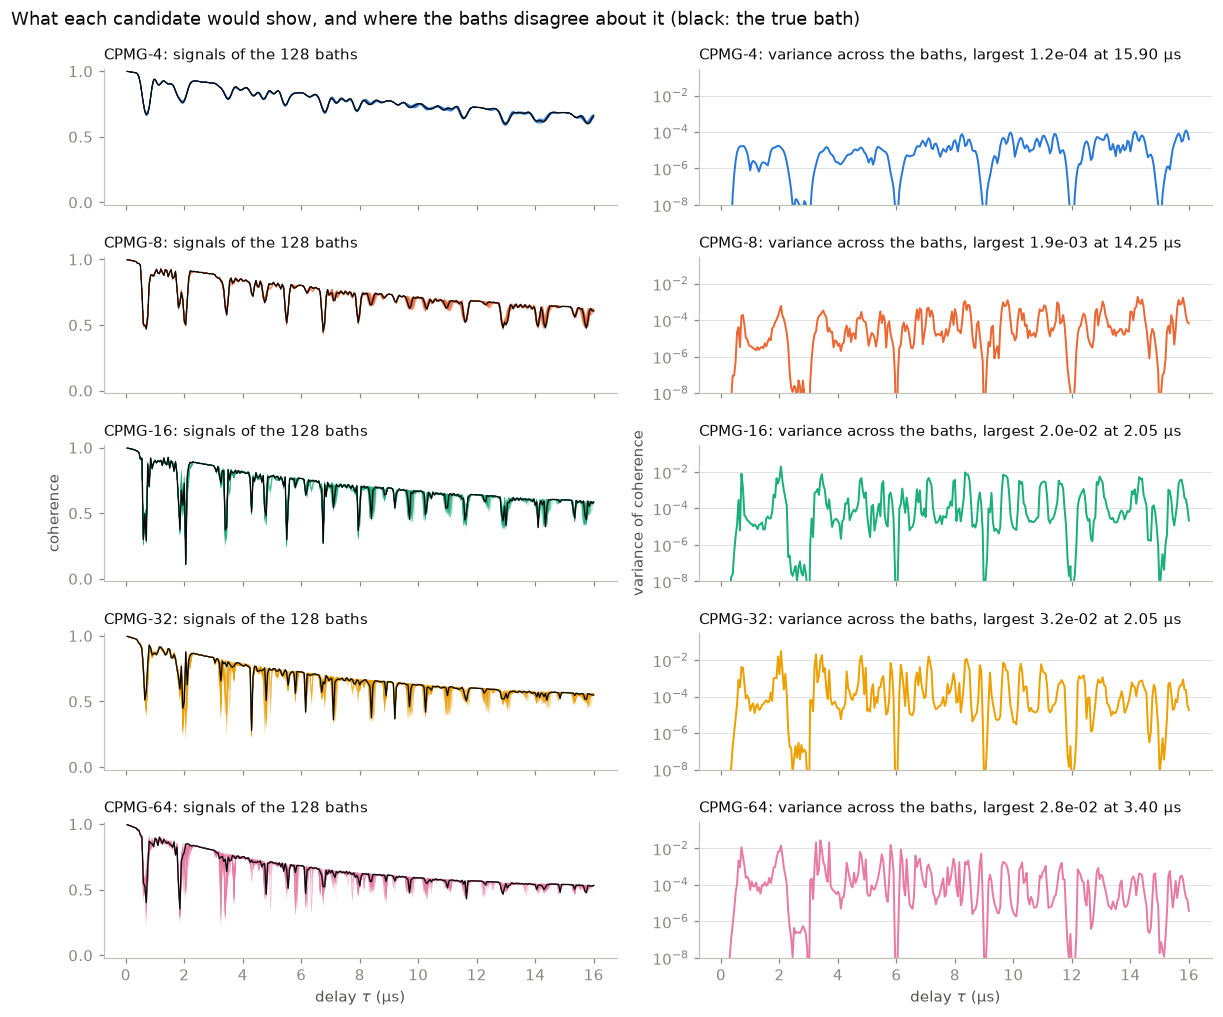

In [7]:
fig, axes = plt.subplots(len(candidates), 2, figsize=(13.0, 10.5), sharex=True,
                         gridspec_kw={"hspace": 0.38, "wspace": 0.16})
for (left, right), d in zip(axes, designs, strict=True):
    n_pulses, colour = d.n_pulses, PULSE_COLOURS[d.n_pulses]
    tau_grid = d.candidate.tau
    variance = d.density * d.sigma**2
    for i in range(particles.n_particles):
        left.plot(tau_grid * 1e3, d.signals[i], color=colour, lw=0.4,
                  alpha=0.12, zorder=1)
    whole = ExperimentSet([Experiment(tau=tau_grid, n_pulses=n_pulses, b_z=B_Z)])
    left.plot(tau_grid * 1e3,
              model.coherence(truth_state(n_pulses), whole, table)[0],
              color=C_INK, lw=0.9, zorder=2)
    left.set_ylim(-0.02, 1.02)
    left.set_title(f"CPMG-{n_pulses}: signals of the {particles.n_particles} "
                   f"baths", loc="left", fontsize=10, color=C_INK)

    right.plot(tau_grid * 1e3, variance, color=colour, lw=1.3, zorder=2)
    right.set_yscale("log")
    right.set_ylim(1e-8, 0.3)
    right.grid(axis="y")
    right.set_title(f"CPMG-{n_pulses}: variance across the baths, largest "
                    f"{variance.max():.1e} at "
                    f"{tau_grid[np.argmax(variance)] * 1e3:.2f} µs",
                    loc="left", fontsize=10, color=C_INK)
axes[len(axes) // 2, 0].set_ylabel("coherence")
axes[len(axes) // 2, 1].set_ylabel("variance of coherence")
for ax in axes[-1]:
    ax.set_xlabel(r"delay $\tau$ (µs)")
fig.suptitle("What each candidate would show, and where the baths disagree "
             "about it (black: the true bath)", x=0.06, y=0.93, ha="left",
             color=C_INK)
plt.show()

### The same disagreement, per unit of measurement time

The variance divided by the noise variance and by the $2N\tau$ a repetition
at that delay takes. This is the quantity the delays are chosen on.

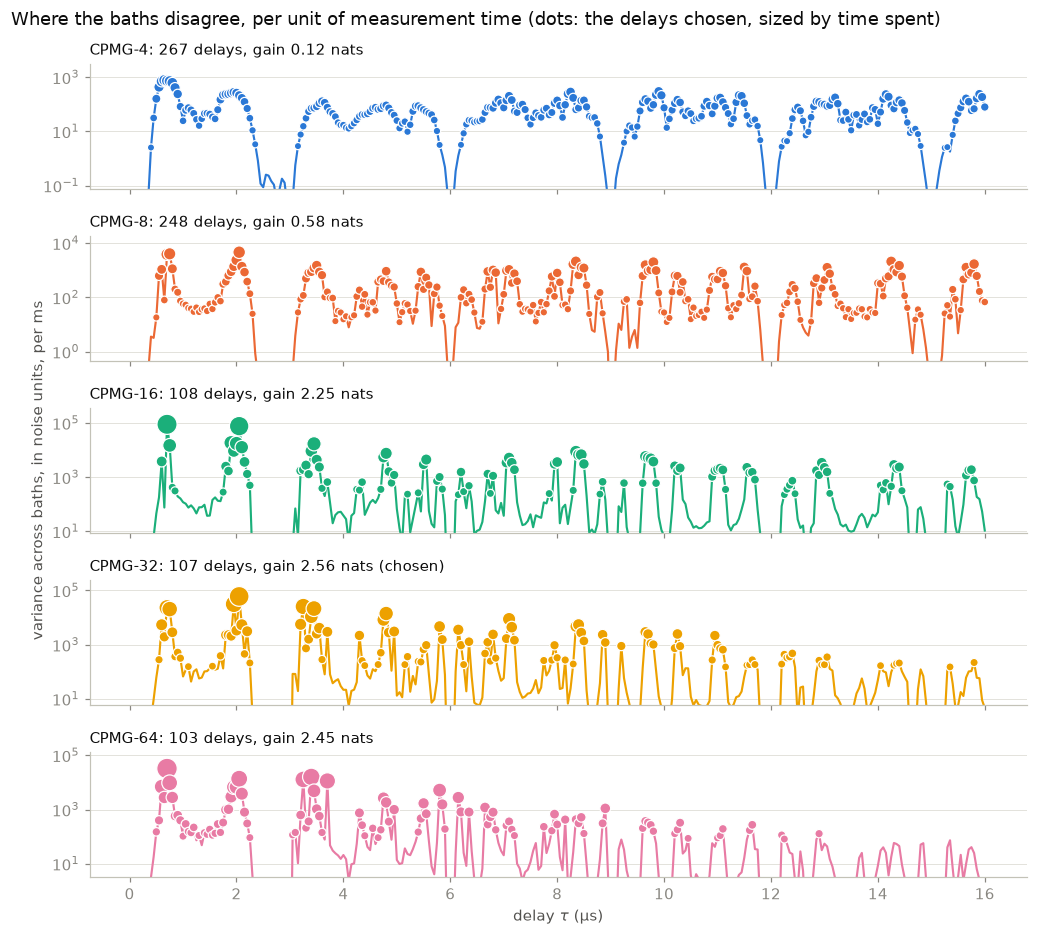

In [8]:
fig, axes = plt.subplots(len(candidates), 1, figsize=(11.0, 9.6), sharex=True,
                         gridspec_kw={"hspace": 0.38})
largest = max(d.time.max() for d in designs if d.time.size)
for ax, d in zip(axes, designs, strict=True):
    colour = PULSE_COLOURS[d.n_pulses]
    ax.plot(d.candidate.tau * 1e3, d.rate, color=colour, lw=1.4, zorder=2)
    ax.scatter(d.tau * 1e3, d.rate[d.index],
               s=20 + 160 * d.time / largest, color=colour,
               edgecolor="white", linewidths=0.8, zorder=3)
    ax.set_yscale("log")
    ax.set_ylim(max(d.rate.max() * 1e-4, 1e-3), d.rate.max() * 4)
    ax.grid(axis="y")
    chosen = " (chosen)" if d.chosen else ""
    ax.set_title(f"CPMG-{d.n_pulses}: {d.tau.size} delays, gain "
                 f"{d.gain:.2f} nats{chosen}", loc="left", fontsize=10,
                 color=C_INK)
axes[len(axes) // 2].set_ylabel("variance across baths, in noise units, per ms")
axes[-1].set_xlabel(r"delay $\tau$ (µs)")
fig.suptitle("Where the baths disagree, per unit of measurement time "
             "(dots: the delays chosen, sized by time spent)",
             x=0.06, y=0.93, ha="left", color=C_INK)
plt.show()

Each panel is one candidate. The curve is how much a unit of time at that
delay separates the baths; the dots are the delays its design measures, and
their size is the time each gets. The designs sit on the peaks, where the
hypotheses predict different dips.

### How many delays: the pruning cut-off

The selector drops a delay whose share of the time is under a set fraction
of the largest share. The designer's default is 0.05, which keeps over a
hundred delays here. The same choice at two higher cut-offs:

In [9]:
print(f"{'cut-off':>8s} {'chosen':>9s} {'delays':>7s} {'gain (nats)':>12s}")
for prune in (0.05, 0.2, 0.5):
    trial = ExperimentDesigner(
        model, table, first, utility=ExpectedInformationGain(n_draws=1000),
        selector=InformationDensity(prune_fraction=prune),
        envelope=DecouplingScaling(GAMMA), min_gain=MIN_GAIN,
    ).propose(particles, candidates, budget=BUDGET, rng=np.random.default_rng(0))
    print(f"{prune:8.2f} {'CPMG-' + str(trial.experiment.n_pulses):>9s} "
          f"{len(trial.experiment):7d} {trial.gain:12.3f}")

 cut-off    chosen  delays  gain (nats)
    0.05   CPMG-32     107        2.564


    0.20   CPMG-64      20        3.147
    0.50   CPMG-64       6        3.116


The cut-off matters here, and the default is not the best of the three. At
0.05 the time is spread over 107 delays, each so briefly measured that the
design gains 2.56 nats. At 0.2 it is concentrated on 20 delays and gains
3.15, and the choice of pulse number moves from 32 to 64. At 0.5 only six
delays are left and the gain is about the same as at 0.2.

This budget is very small, which is when concentrating pays most: there is
not enough time to measure a hundred delays usefully. The rest of the
notebook keeps the default, but for a budget this tight a higher cut-off is
the better design, and the cut-off is worth trying at more than one value
before a measurement is committed to.

## 6. The experiment to run

The output of the whole calculation: one experiment, as a table. Each row
is a delay to measure at. The delays are listed in nanoseconds, with the
free-evolution time of one repetition beside each, and the two share
columns say how to divide the measurement between them.

In [10]:
display(HTML(measurement_table_html(next_experiment, gain=result.gain,
                                    reference_time=FIRST_TIME)))

The same rows are written to `next_experiment.csv`, beside this notebook,
for the instrument or a spreadsheet.

In [11]:
CSV_PATH = write_measurement_csv(next_experiment,
                                 REPO / "notebooks" / "next_experiment.csv")
print(f"wrote {CSV_PATH.relative_to(REPO)}:\n")
print("\n".join(CSV_PATH.read_text().splitlines()[:6]))
print("...")

wrote notebooks/next_experiment.csv:

n_pulses,b_z_gauss,delay_tau_ns,repetition_us,share_of_time,share_of_repetitions,expected_noise
32,311,550.0,35.2000,0.00373,0.01751,0.15335
32,311,600.0,38.4000,0.01644,0.07079,0.07626
32,311,650.0,41.6000,0.00986,0.03917,0.10252
32,311,700.0,44.8000,0.03411,0.12590,0.05718
32,311,750.0,48.0000,0.03199,0.11019,0.06112
...


The proposal is also an `Experiment` object of the package, so once it has
been measured the data can be attached to it and the pair of experiments
fitted together.

## 7. How the gain depends on the budget

A budget can be counted in two ways, and they rank the candidates
differently.

- **In repetitions.** Each candidate is given a multiple of *its own*
  experiment time, the time one pass over its whole grid takes at unit
  weight. Equal multiples mean equal numbers of repetitions. A pass of
  CPMG-64 takes sixteen times as long as a pass of CPMG-4, so on this
  footing the longer sequences are handed more time and are not charged for
  it.
- **In time.** Every candidate is plotted against the measurement time it
  actually uses, in milliseconds. A longer sequence is now always more
  expensive: the same number of repetitions puts it further to the right.

Both panels below are the same designs and the same gains. Only the
horizontal axis differs.

pulses   one pass over the grid   relative to CPMG-4
     4                 20.54 ms                   1x
     8                 41.09 ms                   2x
    16                 82.18 ms                   4x
    32                164.35 ms                   8x
    64                328.70 ms                  16x


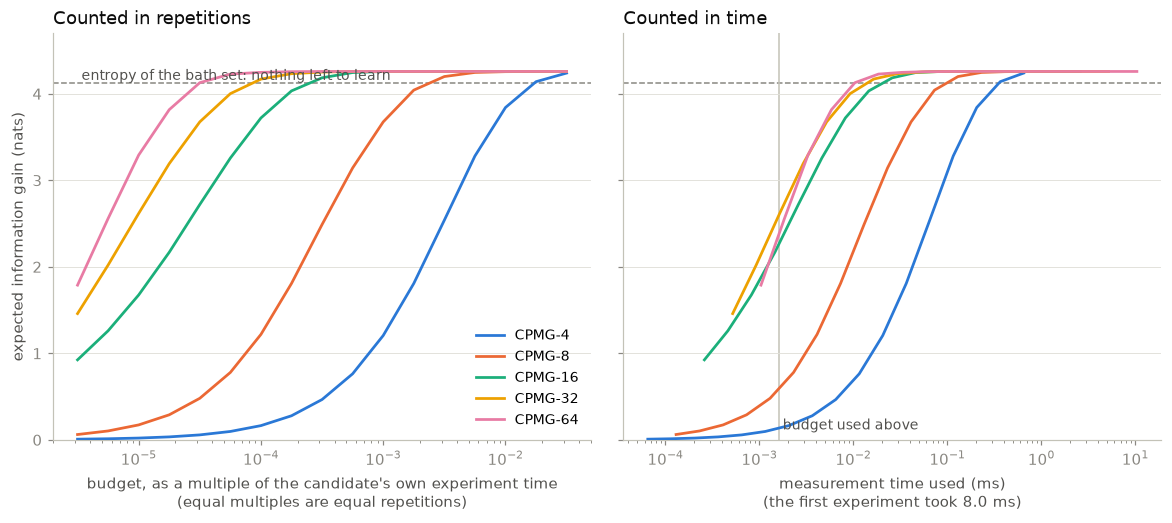

In [12]:
grid_time = np.array([designer.cost_of(c).sum() for c in candidates])
print(f"{'pulses':>6s} {'one pass over the grid':>24s} {'relative to CPMG-4':>20s}")
for c, t in zip(candidates, grid_time, strict=True):
    print(f"{c.n_pulses:6d} {t:21.2f} ms {t / grid_time[0]:19.0f}x")

multiples = np.logspace(-5.5, -1.5, 17)
sweep = ExperimentDesigner(
    model, table, first, utility=ExpectedInformationGain(n_draws=400),
    envelope=DecouplingScaling(GAMMA))
gain_curves = sweep.gain_curve(particles, candidates,
                               multiples[:, None] * grid_time[None, :])

fig, (by_reps, by_time) = plt.subplots(1, 2, figsize=(13.0, 4.8), sharey=True,
                                       gridspec_kw={"wspace": 0.06})
for ax in (by_reps, by_time):
    ax.axhline(ENTROPY, color=C_MUTED, lw=1.0, ls="--", zorder=1)
    ax.set_xscale("log")
    ax.grid(axis="y")
for c, cand in enumerate(candidates):
    colour = PULSE_COLOURS[cand.n_pulses]
    by_reps.plot(multiples, gain_curves[:, c], color=colour, lw=1.8, zorder=3,
                 label=f"CPMG-{cand.n_pulses}")
    by_time.plot(multiples * grid_time[c], gain_curves[:, c], color=colour,
                 lw=1.8, zorder=3)
by_reps.text(multiples[0], ENTROPY, " entropy of the bath set: nothing left "
             "to learn", va="bottom", fontsize=9, color="#52514e")
by_time.axvline(BUDGET, color=C_AXIS, lw=1.0, zorder=1)
by_time.text(BUDGET, 0.12, " budget used above", fontsize=9, color="#52514e")
by_reps.set_ylim(0, ENTROPY * 1.14)
by_reps.set_ylabel("expected information gain (nats)")
by_reps.set_xlabel("budget, as a multiple of the candidate's own experiment "
                   "time\n(equal multiples are equal repetitions)")
by_time.set_xlabel("measurement time used (ms)\n"
                   f"(the first experiment took {FIRST_TIME:.1f} ms)")
by_reps.set_title("Counted in repetitions", loc="left", color=C_INK)
by_time.set_title("Counted in time", loc="left", color=C_INK)
by_reps.legend(loc="lower right", fontsize=9)
plt.show()

Counted in repetitions, more pulses is better without exception: the curves
are ordered by pulse number at every budget. Going from 4 pulses to 8, or
from 8 to 16, reaches the same gain with roughly a tenth of the
repetitions; the further doublings save a factor of two or three. That is
the comparison that flatters long sequences, because the time they take is
not in it.

Counted in time, the long sequences pay for themselves and the curves move
together. CPMG-16, 32 and 64 are nearly on top of one another: 32 is
slightly ahead at the smallest budgets and 64 at larger ones, and the
differences between them are a few tenths of a nat. CPMG-4 and CPMG-8
remain well behind: at this decay rate their dips are too shallow for the
saving in time to make up for.

Every curve climbs to the same ceiling, the entropy of the bath set, which
is the gain from identifying the true bath outright. Once the budget is
large enough for several candidates to reach it, the gain no longer
separates them, and the cheapest of them would be the sensible pick; the
designer does not make that second comparison.

## 8. Running the proposed experiment

A check that the design does what it claims. The chosen experiment is
simulated from the true bath, with the noise its weights imply, and every
bath is reweighted by how well it explains the new data.

Before, the true set of sites holds just under half the weight, and the
rest is on the same three sites with one or two extra spins. After, the
true set holds 92%. The sets with an extra spin on site 5 or site 9 are
ruled out; the remaining 8% is on the true set plus site 1, the weakly
coupled site that the four-pulse data could not decide, which this design
makes unlikely without excluding.

The entropy does not fall to zero. Most of what remains is spread over
baths that share the true sites and differ in how far their couplings have
relaxed.

In [13]:
design = result.chosen
new_exp = ExperimentSet([Experiment(tau=next_experiment.tau,
                                    n_pulses=next_experiment.n_pulses, b_z=B_Z)])
clean = model.coherence(truth_state(next_experiment.n_pulses), new_exp, table)[0]
point_noise = next_experiment.sigma / np.sqrt(next_experiment.weight)
measured = clean + np.random.default_rng(21).normal(0.0, point_noise)

predicted = design.signals[:, design.index]
log_like = -0.5 * np.sum(((measured - predicted) / point_noise) ** 2, axis=1)
updated = weights * np.exp(log_like - log_like.max())
updated /= updated.sum()

after = collections.Counter()
for i in range(particles.n_particles):
    after[site_set(particles, i)] += updated[i]
entropy_after = float(-np.sum(updated[updated > 0] * np.log(updated[updated > 0])))
print(f"entropy of the bath set: {ENTROPY:.2f} nats before, "
      f"{entropy_after:.2f} after; expected gain was {design.gain:.2f}")
print(f"\n{'occupied sites':18s} {'before':>8s} {'after':>8s}")
for sites, _ in set_weight.most_common():
    tag = "   <- the true set" if sites == TRUE_SITES else ""
    print(f"{list(sites)!s:18s} {set_weight[sites]:8.1%} "
          f"{after.get(sites, 0.0):8.1%}{tag}")

entropy of the bath set: 4.12 nats before, 1.60 after; expected gain was 2.56

occupied sites       before    after
[2, 3, 7]             47.4%    92.3%   <- the true set
[1, 2, 3, 7]          28.9%     7.7%
[2, 3, 7, 9]           8.7%     0.0%
[1, 2, 3, 7, 9]        7.8%     0.0%
[2, 3, 5, 7]           5.1%     0.0%
[1, 2, 3, 5, 7]        2.1%     0.0%


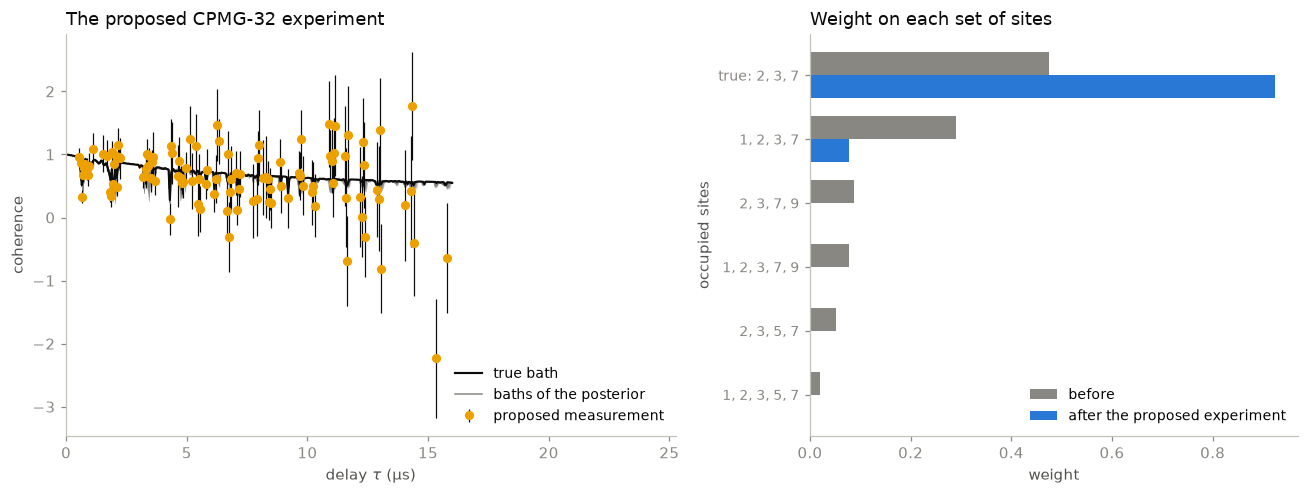

In [14]:
shown = [s for s, _ in set_weight.most_common(7)]
for s, _ in after.most_common(3):
    if s not in shown:
        shown.append(s)
labels = [("true: " if s == TRUE_SITES else "") + ", ".join(map(str, s))
          for s in shown]
y = np.arange(len(shown))
tau_grid = design.candidate.tau

fig, (left, right) = plt.subplots(1, 2, figsize=(12.0, 4.6),
                                  gridspec_kw={"width_ratios": [1.25, 1]})
for i in range(particles.n_particles):
    left.plot(tau_grid * 1e3, design.signals[i], color=C_MUTED, lw=0.5,
              alpha=0.25, zorder=1)
full = ExperimentSet([Experiment(tau=tau_grid, n_pulses=design.n_pulses,
                                 b_z=B_Z)])
left.plot(tau_grid * 1e3,
          model.coherence(truth_state(design.n_pulses), full, table)[0],
          color=C_INK, lw=1.4, zorder=2, label="true bath")
left.plot([], [], color=C_MUTED, lw=1.0, label="baths of the posterior")
left.errorbar(design.tau * 1e3, measured, yerr=point_noise, fmt="o", ms=5,
              color=PULSE_COLOURS[design.n_pulses], ecolor=C_INK,
              elinewidth=0.8, zorder=3, label="proposed measurement")
left.set_xlim(0, design.tau.max() * 1e3 * 1.6)
left.set_xlabel(r"delay $\tau$ (µs)")
left.set_ylabel("coherence")
left.set_title(f"The proposed CPMG-{design.n_pulses} experiment", loc="left",
               color=C_INK)
left.legend(loc="lower right", fontsize=9)

height = 0.36
right.barh(y - height / 2, [set_weight.get(s, 0.0) for s in shown], height,
           color=C_BEFORE, label="before")
right.barh(y + height / 2, [after.get(s, 0.0) for s in shown], height,
           color=C_AFTER, label="after the proposed experiment")
right.set_yticks(y, labels, fontsize=9)
right.invert_yaxis()
right.set_xlabel("weight")
right.set_ylabel("occupied sites")
right.set_title("Weight on each set of sites", loc="left", color=C_INK)
right.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

## 9. A list on which nothing helps

The same posterior, offered only very short delays, below 0.25 µs. No bath
has a dip that early, so every bath predicts the same flat signal there.

In [15]:
short = np.linspace(0.02e-3, 0.25e-3, 40)
nothing = designer.propose(particles, [candidate(4, short), candidate(8, short)],
                           budget=BUDGET, rng=np.random.default_rng(0))
print(nothing)
print(f"\nproposed experiment: {nothing.experiment}")

pulses  points     delays (us)  gain (nats)
     4      26     0.10 - 0.25       -0.000
     8      13     0.18 - 0.25        0.000

No experiment on this list can tell the baths apart: the best gains 0.000 nats, under the threshold of 0.05 nats.

proposed experiment: None


`propose` returns no experiment here, and says why. The gains are not
exactly zero, and one of them may be slightly negative: the estimate is an
average over simulated datasets and scatters around the true value. That
scatter is why the test is a threshold and not a comparison with zero.

## 10. What this assumes

- **The decay at an unmeasured pulse number** comes from the scaling with
  $\gamma$ in section 1. Only four pulses have been measured, so every
  other candidate is designed against an extrapolated decay.
- **The noise of a new point** is the data noise of the first experiment at
  unit weight. It is taken as known.
- **The pooled weights** stand in for posterior probabilities, and section 2
  explains why they are not.
- **The gain is capped by the entropy of the bath set**, which depends on
  the grouping tolerance. The gains are comparable between candidates at one
  tolerance, not between tolerances.
- **The delays of a candidate are chosen by the variance rule**, and only
  the finished design is scored by expected information gain. A search over
  subsets scored by gain directly would be a stronger, slower version.
- **Time is $2N\tau$ and nothing else.** There is no per-shot overhead for
  initialisation and readout, which in a real experiment favours fewer,
  longer repetitions than this does. `SequenceDuration(overhead=...)` adds
  it.